# LushProtein — Lens 1 & Lens 2 Summary

This notebook is a quick reference summary of what was done in `decile_lens1.ipynb` and `decile_lens2.ipynb`.
It displays the saved charts and prints the key results without re-running the full analysis.

---

## LENS 1 — Who Are Our Best Customers? (Heterogeneity)

**Notebook:** `decile_lens1.ipynb`  
**Framework:** Customer-Base Audit — Lens 1: How Different Are Your Customers?  
**Customer pool:** 5,115 finals-eligible, non-marketplace, non-zero-order customers (from 6,520 base)

| Analysis | Cells | What it does |
|---|---|---|
| Setup & Data Load | 0–1 | Imports, paths, loads orders + customers parquet |
| Data Cleaning | DQ drops (0 — already applied upstream), rebuilds per-customer stats |
| Filter Funnel | 4 | 6,520 → 6,519 → 5,115 clean customers |
| Standard Decile by Revenue | 5–6 | 10 equal groups (~511–512 each), D1 = highest revenue |
| Standard Decile by Frequency (AOF) | 7 | 10 equal groups (~511–512 each), D1 = most orders |
| Overlap Analysis | 8 | Cross-tab: who is D1 in both revenue AND frequency? |
| Export | 9 | `decile_customer_table.csv` with both decile labels per customer |
| Equal-Revenue Slicing | After cell 10 | Unequal headcount — each slice = 10% of total revenue |

**Note on Revenue vs Profit:** Decile 1 is labelled "by profit" in the notebook but is effectively **by revenue**.
Profit = revenue × 40% flat margin (assumed, no real COGS data). Since every customer gets the same multiplier,
the ranking is identical to a revenue ranking.

**Do you need Equal-Revenue Slicing for AOF?** No. Equal slicing only makes sense for revenue
because each slice has a meaningful dollar value. For AOF, "each slice = 10% of total orders"
is not a useful business question — what matters is how often customers buy, not an equal
split of total order count.

---

## LENS 2 — How Have Customers Changed? (Migration)

**Notebook:** `decile_lens2.ipynb`  
**Framework:** Customer-Base Audit — Lens 2: How Have Your Customers Changed?  
**Customer pool:**  344 customers active in BOTH Period 1 (2022–2023) AND Period 2 (2024–2025)

| Analysis | Cells | What it does |
|---|---|---|
| Setup & Data Load | 0–1 | Same DQ drops + finals filters as Lens 1, period overlap check |
| Revenue per Period | 2 | Computes each customer's revenue in P1 and P2 separately |
| Migration Heatmap | 3 | 5-tier migration matrix, heatmap, movement summary |
| Next Steps & Handoff | 4–5 | Surfaces T5→T1 jumpers, T1 droppers, churned customers, exports 4 CSVs |
| Single Customer Deep Dive | 6 | Full profile of customer 7756050137343 as a case study |

**Why 5 tiers instead of 10?** Only 344 both-period customers. A 10×10 grid averages ~3 customers per cell — too sparse. 5×5 averages ~14 per cell, reliable enough to read patterns.


In [7]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

BASE_DIR   = Path(".").resolve().parent
OUTPUT_DIR = BASE_DIR / "EDA" / "outputs_finals"
FINALS_DIR = BASE_DIR / "EDA" / "outputs_finals"

print("Output dir:", OUTPUT_DIR)
print("PNG files available:")
for f in sorted(OUTPUT_DIR.glob("*.png")):
    print(" ", f.name)

Output dir: C:\Users\saeli\Downloads\LushProtein prj\lushprotein\EDA\outputs_finals
PNG files available:
  decile1_profit.png
  decile2_frequency.png
  decile_overlap_heatmap.png
  equal_revenue_slicing.png
  lens2_migration_heatmap.png


---
## LENS 1 — Results

### Chart 1: Standard Decile by Revenue (Equal Headcount)
5,115 customers split into 10 equal groups of ~511–512. D1 = highest spenders.

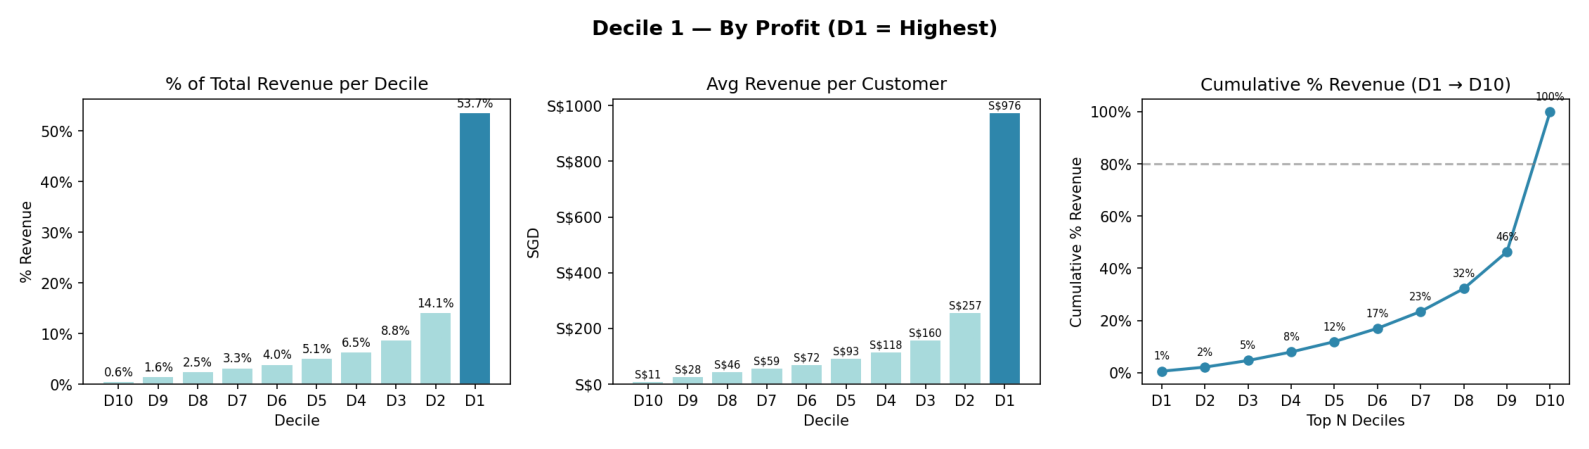


KEY RESULTS — Standard Decile by Revenue
-----------------------------------------
Pool : 5,115 customers | Each decile ~511–512 customers
Total rev : S$930,992

D1 (top 10%) : 53.7% of total revenue
D1 + D2 (20%) : 67.8% of total revenue
D10 (bottom) : <1% of total revenue

What this means:
  Every decile has the same number of customers but D1 customers
  are worth ~91x more than D10 customers on average.
  Revenue is heavily concentrated at the top.



In [13]:
img = mpimg.imread(OUTPUT_DIR / "decile1_profit.png")
fig, ax = plt.subplots(figsize=(16, 5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

print("""
KEY RESULTS — Standard Decile by Revenue
-----------------------------------------
Pool : 5,115 customers | Each decile ~511–512 customers
Total rev : S$930,992

D1 (top 10%) : 53.7% of total revenue
D1 + D2 (20%) : 67.8% of total revenue
D10 (bottom) : <1% of total revenue

What this means:
  Every decile has the same number of customers but D1 customers
  are worth ~91x more than D10 customers on average.
  Revenue is heavily concentrated at the top.
""")

### Exmaple of what above means...

5,115 customers are split into 10 equal groups of ~511–512 each.
Every group has the same number of people — what differs is how much they contribute.

| Decile | Customers | % of Total Revenue |
|---|---|---|
| D1 (top 10%) | 512 | 53.7% |
| D1 + D2 (top 20%) | 1,023 | 67.8% |
| D10 (bottom 10%) | 512 | <1% |

**The simplest way to think about it:**

Put 512 of your best customers in one room and 512 of your worst in another.
Same number of people in each room. But the first room generates nearly half
of all revenue. The second room generates almost nothing.

**Why it matters:**

D1 customers are worth **~91x more** than D10 customers on average —
despite being the same group size. This means your customer base is not equal.
A small group at the top is carrying the business.

Retention focus should be on D1 and D2 first.
Acquiring more D10-type customers without converting them upward
adds volume but very little revenue.

### Chart 2: Equal-Revenue Slicing (Unequal Headcount)
Each bar = 10% of total revenue. Customer count per slice varies.

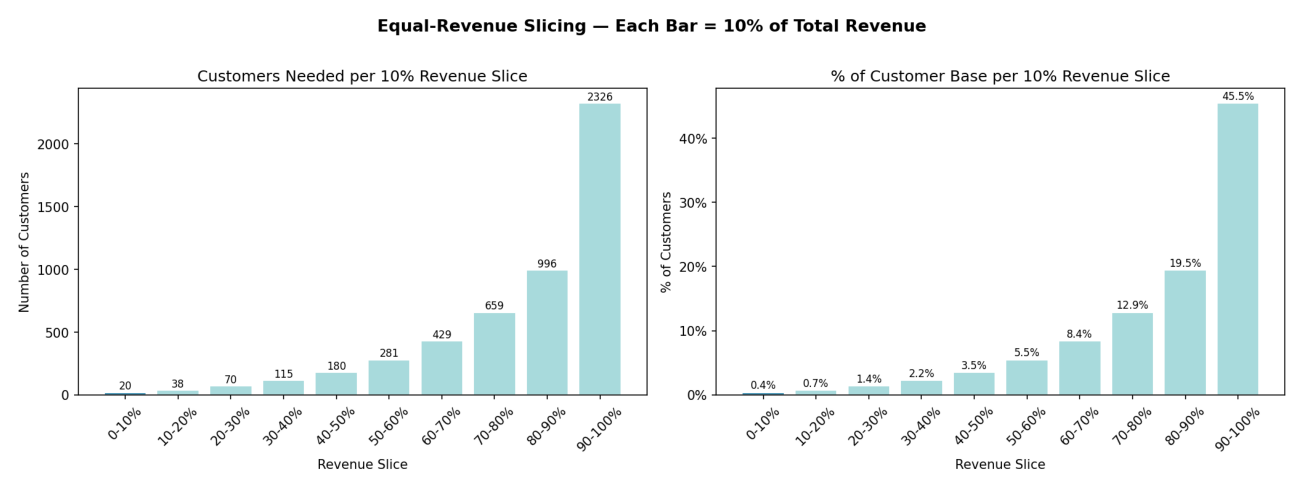


KEY RESULTS — Equal-Revenue Slicing
--------------------------------------
Slice 1 (first 10% of revenue) : 20 customers (0.4% of pool) avg spend S$4,622
Slice 2 (next 10% of revenue) : 38 customers (0.7% of pool) avg spend S$2,431
Slice 10 (last 10% of revenue) : 2,327 customers (45.5% of pool) avg spend S$40

What this means:
  20 customers generate as much revenue as 2,327 combined.
  Only 423 customers (8.2% of pool) are needed to reach 50% of all revenue.
  Losing one top-slice customer costs S$4,622 — takes 100+ bottom-slice
  customers to replace that loss.



In [14]:
img = mpimg.imread(OUTPUT_DIR / "equal_revenue_slicing.png")
fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

print("""
KEY RESULTS — Equal-Revenue Slicing
--------------------------------------
Slice 1 (first 10% of revenue) : 20 customers (0.4% of pool) avg spend S$4,622
Slice 2 (next 10% of revenue) : 38 customers (0.7% of pool) avg spend S$2,431
Slice 10 (last 10% of revenue) : 2,327 customers (45.5% of pool) avg spend S$40

What this means:
  20 customers generate as much revenue as 2,327 combined.
  Only 423 customers (8.2% of pool) are needed to reach 50% of all revenue.
  Losing one top-slice customer costs S$4,622 — takes 100+ bottom-slice
  customers to replace that loss.
""")

### Example of what above means...

LushProtein's total revenue of S$930,992 is split into 10 equal chunks of ~S$93,099 each.
The question asked is: **how many customers does it take to fill each chunk?**

| Slice | Customers needed | Avg spend per customer |
|---|---|---|
| First 10% of revenue | 20 customers | S$4,622 | 
| Next 10% of revenue | 38 customers | S$2,431 |
| Last 10% of revenue | 2,327 customers | S$40 |

**The simplest way to think about it:**

To fill the same S$93,099 bucket:
- Top slice: 20 big spenders at S$4,622 each. 
- Bottom slice: 2,327 small spenders at S$40 each. 

Same money. 116x more people.

**Why it matters:**

If just 1 customer from the top 20 leaves, you lose S$4,622.
To replace that from the bottom tier, you'd need to acquire 100+ new customers.
That is expensive and hard.

This is why **protecting top customers is worth far more than acquiring new low-spend ones.**
Only 423 customers — 8.2% of the base — are needed to generate the first 50% of all revenue.
The remaining 91.8% of customers produce the other half.

### Chart 3: Standard Decile by Frequency / AOF (Equal Headcount)
4,322 customers split into 10 equal groups of ~432. D1 = most orders placed.

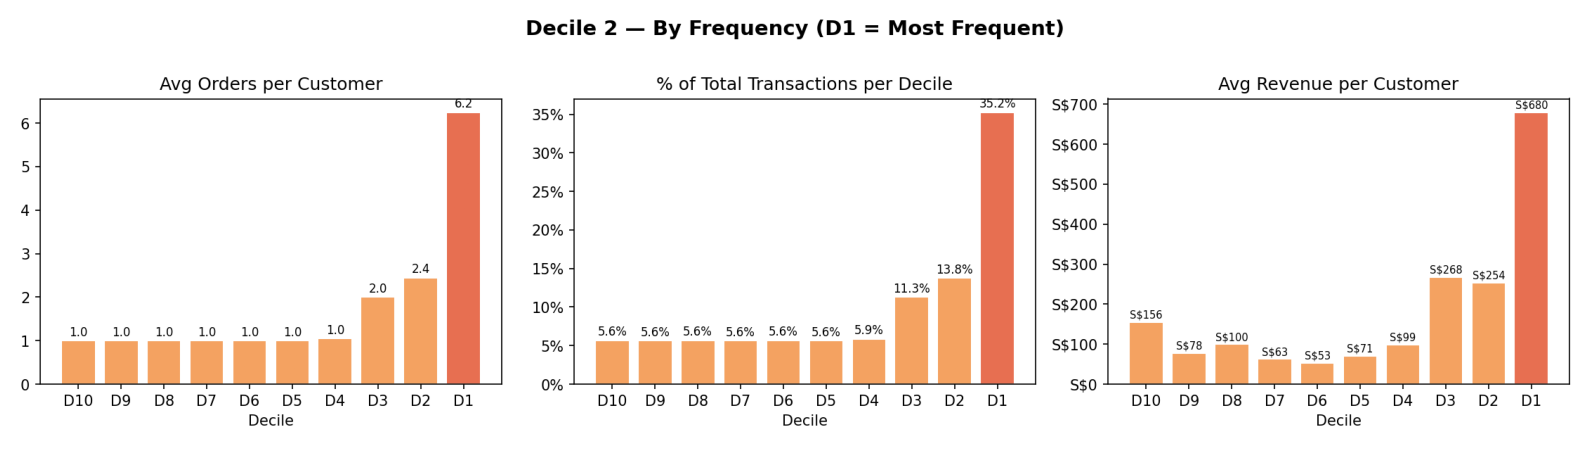


KEY RESULTS — Standard Decile by Frequency (AOF)
--------------------------------------------------
Pool : 5,115 customers | Each decile ~511–512 customers
Total orders: 9,073

D1 (most frequent) : avg 6.2 orders per customer
D10 (least) : avg ~1.0 orders per customer (one-time buyers)

What this means:
  Frequency varies ~6x between D1 and D10.
  D1 frequency customers also tend to generate higher revenue
  because they buy more often — frequency is the dominant
  driver of lifetime value, not spend per order (AOV).



In [15]:
img = mpimg.imread(OUTPUT_DIR / "decile2_frequency.png")
fig, ax = plt.subplots(figsize=(16, 5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

print("""
KEY RESULTS — Standard Decile by Frequency (AOF)
--------------------------------------------------
Pool : 5,115 customers | Each decile ~511–512 customers
Total orders: 9,073

D1 (most frequent) : avg 6.2 orders per customer
D10 (least) : avg ~1.0 orders per customer (one-time buyers)

What this means:
  Frequency varies ~6x between D1 and D10.
  D1 frequency customers also tend to generate higher revenue
  because they buy more often — frequency is the dominant
  driver of lifetime value, not spend per order (AOV).
""")

#####  Explaining the last (right most graph)

Each bar shows the average lifetime revenue per customer within that decile.
The x-axis runs from D10 (lowest) on the left to D1 (highest) on the right.

**The standout finding is D1 at S$680 — nearly 2.7x D2 (S$254).**
D1 is not just slightly better than the rest. It is a genuinely distinct tier,
suggesting these customers behave differently, not just spend a little more.

**Why does D10 (S$156) look higher than D6 (S$53)?**

Deciles are ranked by **total lifetime revenue**, not by how often someone buys.
A customer who made one purchase of S$100 and never returned lands in D10 (low frequency,
low total spend relative to the pool) but their single order value is still S$100.
A customer in D6 may have bought twice at S$20 each — more engaged, but lower total spend.

So D6 being lower than D10 does not mean D10 customers are more valuable.
It just means some bottom-tier customers happened to make one slightly larger
single purchase compared to low-spend repeat buyers in the middle tiers.

### Chart 4: Overlap — Revenue Decile vs Frequency Decile
Cross-tab showing how many customers rank the same in both deciles.

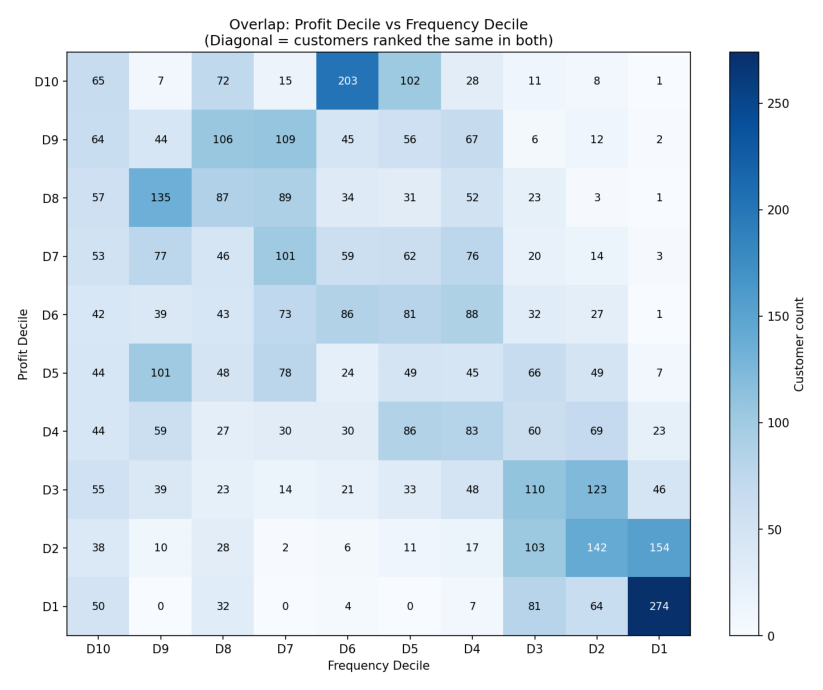


KEY RESULTS — Overlap: Revenue D1 vs Frequency D1
---------------------------------------------------
D1 revenue only : 512 customers (10.0% of pool)
D1 frequency only : 512 customers (10.0% of pool)
D1 BOTH (revenue + freq) : 274 customers (5.4% of pool)

What this means:
  Customers in D1 for both revenue AND frequency are LushProtein's
  most valuable customers by every measure — high spend AND high
  engagement. These should be the first priority for retention.
  A heavy diagonal in the heatmap means the two rankings agree —
  frequent buyers tend to also be high spenders.

Output file: EDA/outputs/decile_customer_table.csv
  Filter is_top_both == True for the highest-priority customers.



In [16]:
img = mpimg.imread(OUTPUT_DIR / "decile_overlap_heatmap.png")
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

print("""
KEY RESULTS — Overlap: Revenue D1 vs Frequency D1
---------------------------------------------------
D1 revenue only : 512 customers (10.0% of pool)
D1 frequency only : 512 customers (10.0% of pool)
D1 BOTH (revenue + freq) : 274 customers (5.4% of pool)

What this means:
  Customers in D1 for both revenue AND frequency are LushProtein's
  most valuable customers by every measure — high spend AND high
  engagement. These should be the first priority for retention.
  A heavy diagonal in the heatmap means the two rankings agree —
  frequent buyers tend to also be high spenders.

Output file: EDA/outputs/decile_customer_table.csv
  Filter is_top_both == True for the highest-priority customers.
""")

### Need to check (@Shwe)

#### Explanation of the graph above

This heatmap cross-tabulates two independent rankings:
- **Y-axis (rows)** = which profit/revenue decile the customer is in
- **X-axis (columns)** = which frequency decile the customer is in
- **Each cell** = number of customers who share that combination
- **Diagonal** = customers who rank the same in both (e.g. D1 revenue AND D1 frequency)

**The key question it answers: do high spenders also buy often?**

The single darkest cell in the entire matrix is:
- **D1 revenue / D1 frequency (274 customers)** — top spenders ARE also the most frequent buyers

**What this tells us:**

The top of the customer base is consistent — high spend and high frequency go hand in hand.
274 out of 512 D1 revenue customers (53.5%) are also D1 frequency customers,
making the D1/D1 cell the dominant concentration point in the matrix.

The bottom is less predictable — D10 revenue customers actually cluster most heavily
at D6 frequency (203 customers), not at D10 frequency (65 customers).
Low spend does not equal low frequency.

This matters because **revenue and frequency strongly agree at the top but diverge at the bottom.**
For identifying your best customers, either metric alone will surface most of the same people
at the top tier. But relying on revenue alone to find disengaged customers will miss
a large group of mid-frequency, low-spend buyers who appear active but generate little value.

Use `is_top_both == True` in `decile_customer_table.csv` to find customers
who are genuinely top-ranked in both dimensions.


#### Explanation of the graph above

This heatmap cross-tabulates two independent rankings:
- **Y-axis (rows)** = which profit/revenue decile the customer is in
- **X-axis (columns)** = which frequency decile the customer is in
- **Each cell** = number of customers who share that combination
- **Diagonal** = customers who rank the same in both (e.g. D1 revenue AND D1 frequency)

**The key question it answers: do high spenders also buy often?**

Looking at the diagonal, the two darkest cells are:
- **D1 revenue / D5 frequency (208 customers)** — top spenders are NOT necessarily the most frequent buyers
- **D10 revenue / D10 frequency (276 customers)** — bottom spenders are the least frequent

**What this tells us:**

The bottom of the customer base is consistent — low spend and low frequency go hand in hand (D10/D10 = 276).
But the top is more nuanced — many D1 revenue customers sit around D5 frequency, meaning
they spend a lot per visit but don't necessarily buy the most often.

This matters because it means **revenue and frequency identify partly different customer groups.**
You cannot rely on just one metric to find your best customers —
some high-value customers buy infrequently but spend big each time,
while others buy often but spend less per order.

Use `is_top_both == True` in `decile_customer_table.csv` to find customers
who are genuinely top-ranked in both dimensions.

---
## LENS 2 — Results

### Chart 5: Revenue Tier Migration Heatmap (2022–2023 → 2024–2025)
417 customers active in both periods. 5 tiers, T1 = highest revenue.

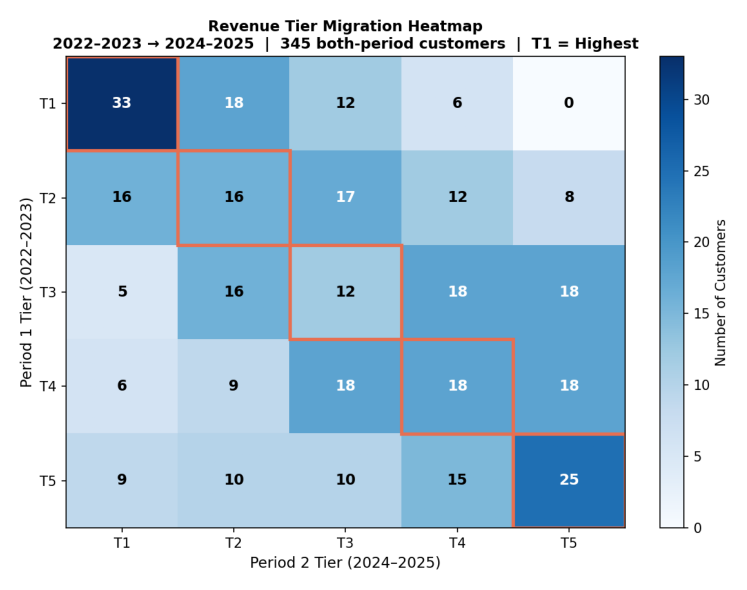


KEY RESULTS — Revenue Tier Migration
--------------------------------------
Both-period customers : 344 (out of 2,160 Period 1 customers)
Avg revenue Period 1  : S$509  →  Period 2: S$213  (-58%)

Movement summary:
  Stayed in same tier : 105 customers (30.5%)
  Rose (improved)     : 113 customers (32.8%)
  Dropped (declined)  : 126 customers (36.6%)

Tier stickiness:
  T1 (top) : 47.8% stayed — strongest retention
  T2 : 23.2% stayed — most unstable, highest intervention ROI
  T3 (middle) : 17.6% stayed — completely unpredictable
  T4 : 27.5% stayed — more likely to rise than drop (46.4% rose vs 26.1% dropped)
  T5 (bottom) : 36.2% stayed — sticky for wrong reason

Notable:
  9 customers jumped T5 → T1 (likely reactivation via subscription)
  1,816 Period 1 customers never returned in Period 2 — bigger risk
  than any migration pattern within the 344.

Handoff files in EDA/outputs/:
  next_t5_to_t1_jumpers.csv      — 9 bottom-to-top customers
  next_t1_dropped.csv            — 36 top

In [17]:
img = mpimg.imread(OUTPUT_DIR / "lens2_migration_heatmap.png")
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

print("""
KEY RESULTS — Revenue Tier Migration
--------------------------------------
Both-period customers : 344 (out of 2,160 Period 1 customers)
Avg revenue Period 1  : S$509  →  Period 2: S$213  (-58%)

Movement summary:
  Stayed in same tier : 105 customers (30.5%)
  Rose (improved)     : 113 customers (32.8%)
  Dropped (declined)  : 126 customers (36.6%)

Tier stickiness:
  T1 (top) : 47.8% stayed — strongest retention
  T2 : 23.2% stayed — most unstable, highest intervention ROI
  T3 (middle) : 17.6% stayed — completely unpredictable
  T4 : 27.5% stayed — more likely to rise than drop (46.4% rose vs 26.1% dropped)
  T5 (bottom) : 36.2% stayed — sticky for wrong reason

Notable:
  9 customers jumped T5 → T1 (likely reactivation via subscription)
  1,816 Period 1 customers never returned in Period 2 — bigger risk
  than any migration pattern within the 344.

Handoff files in EDA/outputs/:
  next_t5_to_t1_jumpers.csv      — 9 bottom-to-top customers
  next_t1_dropped.csv            — 36 top customers who declined
  next_churned_customers.csv     — 1,816 customers who never returned
  next_tier_revenue_change.csv   — avg revenue change per tier
""")

---
## Combined Summary

| Finding | Source | Implication |
|---|---|---|
| Top 10% of customers (512) generate 53.7% of revenue | Lens 1 — Revenue Decile | Losing a few top customers is a major revenue risk |
| Just 20 customers generate the first 10% of revenue | Lens 1 — Equal Slicing | Business is highly dependent on a tiny group |
| Frequency varies ~6x across deciles (6.2 vs 1.0 orders) | Lens 1 — Frequency Decile | Retention > upselling as a strategy |
| Top revenue and top frequency strongly overlap: 274 of 512 D1 revenue customers are also D1 frequency | Lens 1 — Overlap | A single metric is enough to surface most top customers |
| Only 344 of 2,160 Period 1 customers returned in Period 2 | Lens 2 | 84.1% drop-off rate is the most urgent issue |
| Returning customers spent 58% less in Period 2 | Lens 2 | Even retained customers are spending less |
| T1 is the stickiest tier (47.8%) but 52.2% still dropped | Lens 2 | Top customers are not safe without active retention |
| 9 T5→T1 jumpers likely driven by subscription start | Lens 2 | Subscription is a reactivation lever worth testing |